## 美国核电产能与趋势分析

本研究以美国近年来核电产能以及使用趋势的研究数据为基础，对美国的核电产业进行数据化分析项目重点为
* 年度核电产值与使用的变化率
* 各地区的核电使用情况及其变化率
* 产业结构分析
* 总体产业分析

**一，获取数据**

In [12]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 获取美国核电数据，通过获取其API调用数据

API_KEY = "4uHzt4DHXkT6q7VThHzMRMkE6oF7bCZlq1lnkjia"

url = "https://api.eia.gov/v2/electricity/electric-power-operational-data/data/"
params = {
    "api_key": API_KEY,
    "data[0]": "generation",
    "frequency": "annual",
    "facets[fueltypeid][]": "NUC",
    "sort[0][column]": "period",
    "sort[0][direction]": "desc",
    "length": 2000
}

response = requests.get(url, params=params)
data = response.json()
records = data['response']['data']

df = pd.DataFrame(records)
df = df[['period', 'location', 'stateDescription', 'sectorid', 'sectorDescription',
         'fueltypeid', 'fuelTypeDescription', 'generation', 'generation-units']]

df.to_csv('U202515697.csv', index=False, encoding='utf-8-sig')

**二，美国核电总体趋势分析**

1. 美国年度总产值基本情况以及最值分析

In [13]:
df = pd.read_csv('U202515697.csv')
df_US = df[(df['location'] == 'US') & (df['sectorid'] == 99)]
arr_US = np.array(df_US['generation'])
print(arr_US)

[784780.718   781865.31    774873.169   771537.17649 779644.595
 789878.863   809409.262   807084.477   804949.635   805693.948
 797177.877  ]


In [14]:
print(f"最近{len(arr_US)}年来美国核电全产业的总产值为{np.sum(arr_US)}千兆瓦时，"
      f"其中总产值最大的为{np.max(arr_US)}千兆瓦时，为{2025-np.argmax(arr_US)}年产值")

最近11年来美国核电全产业的总产值为8706895.03049千兆瓦时，其中总产值最大的为809409.262千兆瓦时，为2019年产值


2. 美国年度总产值趋势分析以及折线图绘制

In [15]:
x = []
y = []

for i in range(len(arr_US)):
    year = 2025 - (len(arr_US) - ( i + 1))
    x.append(year)
    y.append(arr_US[len(arr_US) - (i + 1)])

print(x,y)

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] [np.float64(797177.877), np.float64(805693.948), np.float64(804949.635), np.float64(807084.477), np.float64(809409.262), np.float64(789878.863), np.float64(779644.595), np.float64(771537.17649), np.float64(774873.169), np.float64(781865.31), np.float64(784780.718)]


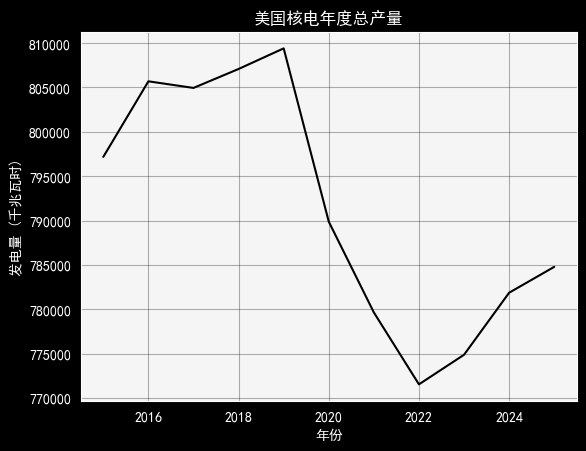

In [16]:
plt.plot(x, y, linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('美国核电年度总产量')
plt.xlabel('年份')
plt.ylabel('发电量 (千兆瓦时)')
plt.grid(True, alpha=0.3,color='black')
plt.show()

3. 年度同比增长率计算

In [17]:
growth_rate = []
values = np.array(df_US['generation'])

for i in range(1,len(arr_US)):
    rate = (values[i] - values[i-1])/values[i-1]*100
    growth_rate.append(rate)

years = np.array(x)
for i in range(0,len(years)-1):
    print(f"{years[i]}年的同比增长率为：{growth_rate[i]:.2f}%")


2015年的同比增长率为：-0.37%
2016年的同比增长率为：-0.89%
2017年的同比增长率为：-0.43%
2018年的同比增长率为：1.05%
2019年的同比增长率为：1.31%
2020年的同比增长率为：2.47%
2021年的同比增长率为：-0.29%
2022年的同比增长率为：-0.26%
2023年的同比增长率为：0.09%
2024年的同比增长率为：-1.06%


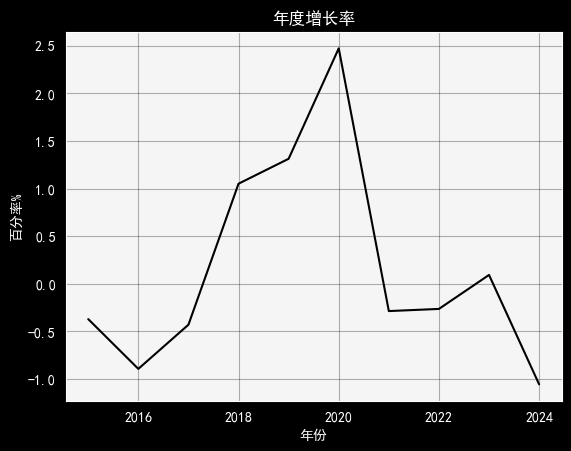

In [27]:
plt_years = years[:-1]
plt.plot(plt_years,growth_rate,linestyle='-', color='black')
plt.gca().set_facecolor('#f5f5f5')
plt.title('年度增长率')
plt.xlabel("年份")
plt.ylabel("百分率%")
plt.grid(True, alpha=0.3,color='black')
plt.show()

**二，各地区核电产能分析**

1. 各地区核电产能排位分析

In [58]:
'''
    AL 阿拉巴马州
    ENC 东北中部地区
    SAT 南大西洋地区
    90 太平洋地区
    ESC 东南中部地区
    MAT 中大西洋地区
    MTN 山区
    NEW 新英格兰地区
    WNC 西北中部地区
    WSC 西南中部地区
    PCC 太平洋沿岸地区
    US 美国全国总计
'''

df = pd.read_csv('U202515697.csv')


df_AL = df[(df['location'] == 'AL') & (df['sectorid'] == 99)]
df_ENC = df[(df['location'] == 'ENC') & (df['sectorid'] == 99)]
df_SAT = df[(df['location'] == 'SAT') & (df['sectorid'] == 99)]
df_90 = df[(df['location'] == '90') & (df['sectorid'] == 99)]
df_ESC = df[(df['location'] == 'ESC') & (df['sectorid'] == 99)]
df_MAT = df[(df['location'] == 'MAT') & (df['sectorid'] == 99)]
df_MTN = df[(df['location'] == 'MTN') & (df['sectorid'] == 99)]
df_NEW = df[(df['location'] == 'NEW') & (df['sectorid'] == 99)]
df_WNC = df[(df['location'] == 'WNC') & (df['sectorid'] == 99)]
df_WSC = df[(df['location'] == 'WSC') & (df['sectorid'] == 99)]
df_PCC = df[(df['location'] == 'PCC') & (df['sectorid'] == 99)]
df_US = df[(df['location'] == 'US') & (df['sectorid'] == 99)]

# 各地区的产值
arr_AL = np.array(df_AL['generation'])
arr_ENC = np.array(df_ENC['generation'])
arr_SAT = np.array(df_SAT['generation'])
arr_90 = np.array(df_90['generation'])
arr_ESC = np.array(df_ESC['generation'])
arr_MAT = np.array(df_MAT['generation'])
arr_MTN = np.array(df_MTN['generation'])
arr_NEW = np.array(df_NEW['generation'])
arr_WNC = np.array(df_WNC['generation'])
arr_WSC = np.array(df_WSC['generation'])
arr_PCC = np.array(df_PCC['generation'])
arr_US = np.array(df_US['generation'])

# 所有地区的总和数组
arr_all_regions = np.array([np.sum(arr_AL), np.sum(arr_ENC), np.sum(arr_SAT), np.sum(arr_90),np.sum(arr_ESC), np.sum(arr_MAT), np.sum(arr_MTN), np.sum(arr_NEW),np.sum(arr_WNC), np.sum(arr_WSC), np.sum(arr_PCC)])

dict_all_regions = {
    0: 'AL',
    1: 'ENC',
    2: 'SAT',
    3: '90',
    4: 'ESC',
    5: 'MAT',
    6: 'MTN',
    7: 'NEW',
    8: 'WNC',
    9: 'WSC',
    10: 'PCC',
}

print(f"全部地区中近十年综合最高产量为{np.max(arr_all_regions):.2f},为{dict_all_regions[np.argmax(arr_all_regions)]}地区")

print(f"美国全国近十年核电总产量为{total_US:.2f}千兆瓦时")

全部地区中近十年综合最高产量为2285602.88,为SAT地区
美国全国近十年核电总产量为9356097.14千兆瓦时


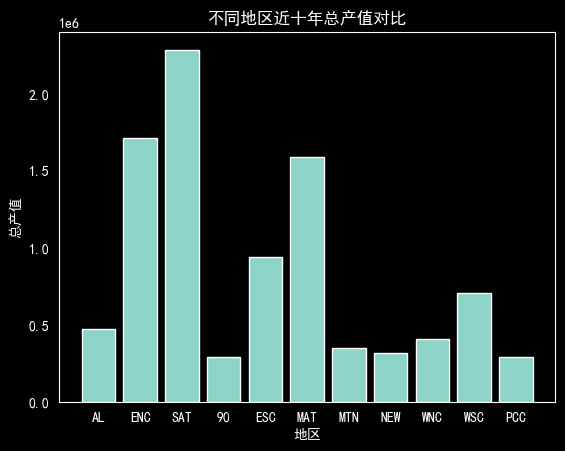

In [38]:
plt.bar(dict_all_regions.values(), arr_all_regions, align='center')
plt.title('不同地区近十年总产值对比')
plt.xlabel('地区')
plt.ylabel('总产值')
plt.grid(True, alpha=0.3,color='black')
plt.show()

2. 地区所占全国市场份额分析

In [80]:
# 定义计算市场份额的函数 方便后续调用以及数据分析
dict_states_generation = dict(zip(dict_all_regions.values(),arr_all_regions))

def sum_generation(arr):
    return np.sum(arr)

def market_shares(generation, total):
    return generation / total * 100

# 占全美的比例
print("\n各地区占全美总量的市场份额：")
for key, value in dict_states_generation.items():
    share_national = market_shares(value,sum_generation(arr_all_regions) )
    print(f"{key}地区近十年时间内生产总额占全美总量的比例为{share_national:.2f}%")


各地区占全美总量的市场份额：
AL地区近十年时间内生产总额占全美总量的比例为5.05%
ENC地区近十年时间内生产总额占全美总量的比例为18.28%
SAT地区近十年时间内生产总额占全美总量的比例为24.43%
90地区近十年时间内生产总额占全美总量的比例为3.12%
ESC地区近十年时间内生产总额占全美总量的比例为10.06%
MAT地区近十年时间内生产总额占全美总量的比例为16.95%
MTN地区近十年时间内生产总额占全美总量的比例为3.75%
NEW地区近十年时间内生产总额占全美总量的比例为3.36%
WNC地区近十年时间内生产总额占全美总量的比例为4.35%
WSC地区近十年时间内生产总额占全美总量的比例为7.52%
PCC地区近十年时间内生产总额占全美总量的比例为3.12%


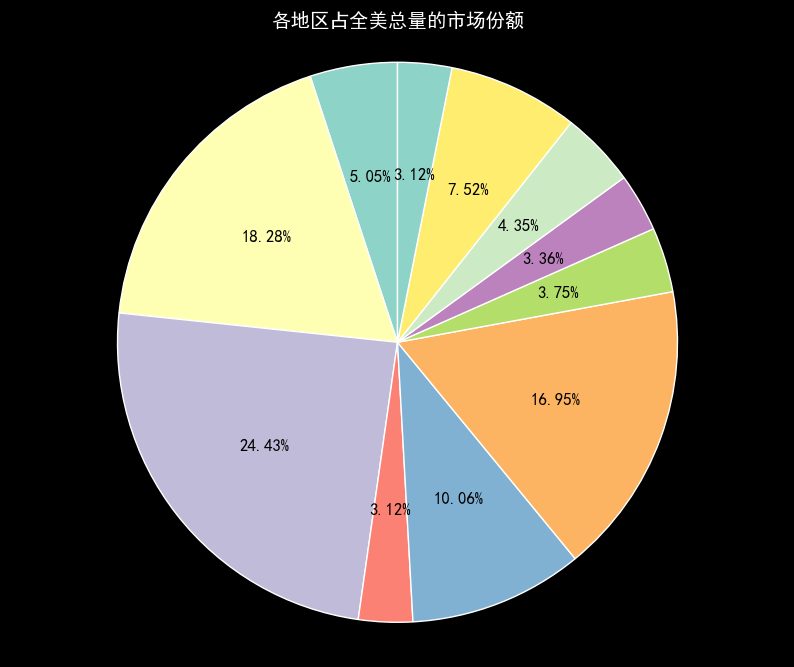

In [63]:
plt.figure(figsize=(10, 8))
plt.pie(arr_all_regions, labels=dict_all_regions.values(), autopct='%1.2f%%', startangle=90,textprops={'color': 'black', 'fontsize': 12})
plt.title('各地区占全美总量的市场份额', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

**三，产业结构与产值分析**

1. 产业结构统计以及逐年各产业产值分析

In [79]:
'''
    99: 全行业统计
    1: 电力公司
    2: 独立发电商
    90: 电力行业非CHP
    98: 电力行业总计
'''
df = pd.read_csv('U202515697.csv')


df_2025_1 = df[(df['sectorid'] == 1) & (df['period'] == 2025)]
df_2025_2 = df[(df['sectorid'] == 2) & (df['period'] == 2025)]
df_2025_90 = df[(df['sectorid'] == 90) & (df['period'] == 2025)]
df_2025_98 = df[(df['sectorid'] == 98) & (df['period'] == 2025)]